In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns 

In [4]:
df = pd.read_csv("C:/Users/ukuja/PycharmProjects/RAM0620/Jupyter lab/väike_log.txt", parse_dates=["date"]) #DataFrame
status_order = ["Healthy", "Warning", "Failure"]
df["health_status"] = pd.Categorical(df["health_status"], categories = status_order, ordered = True)

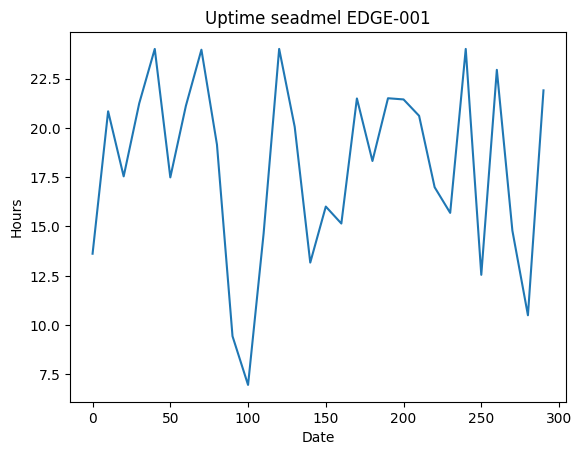

In [5]:
df = df.sort_index()
edge1 = df[df["hostname"] == "EDGE-001"]
edge1["uptime_hours"].plot(kind="line", title="Uptime seadmel EDGE-001")
plt.xlabel("Date")
plt.ylabel("Hours")
plt.show()

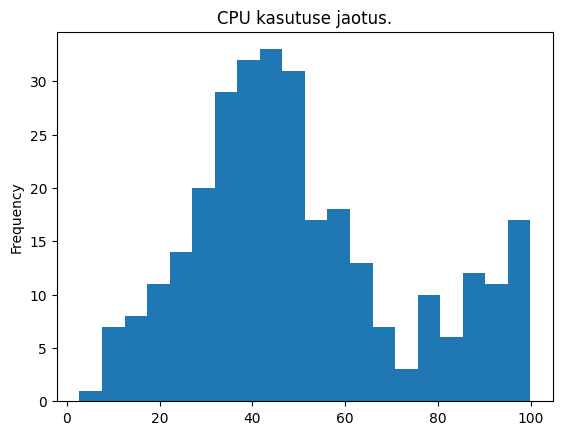

In [6]:
df["cpu_usage_percent"].plot(kind="hist", bins=20)
plt.title("CPU kasutuse jaotus.")
plt.show()

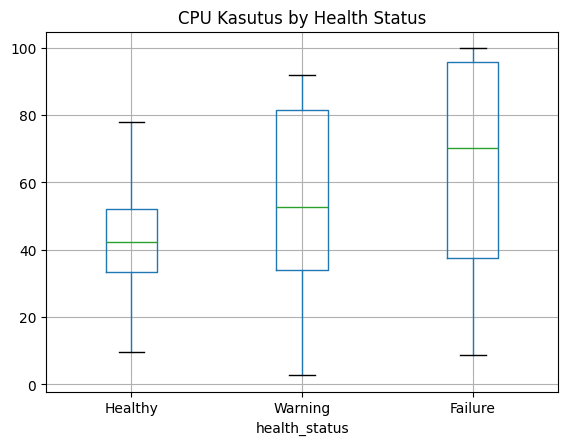

In [7]:
df.boxplot(column="cpu_usage_percent", by="health_status")
plt.suptitle("")
plt.title("CPU Kasutus by Health Status")
plt.show()

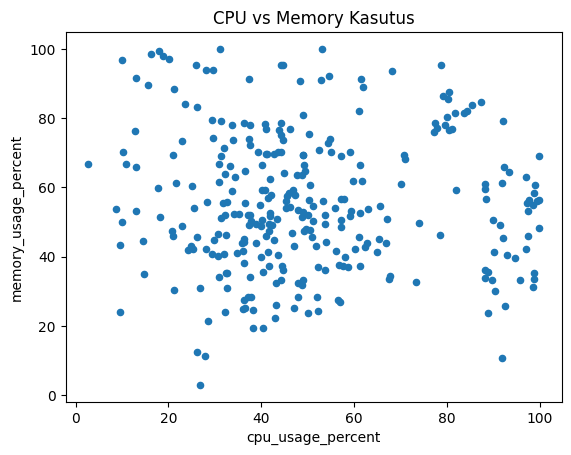

In [8]:
df.plot(kind="scatter",
        x="cpu_usage_percent",
        y="memory_usage_percent",
        title="CPU vs Memory Kasutus")
plt.show()

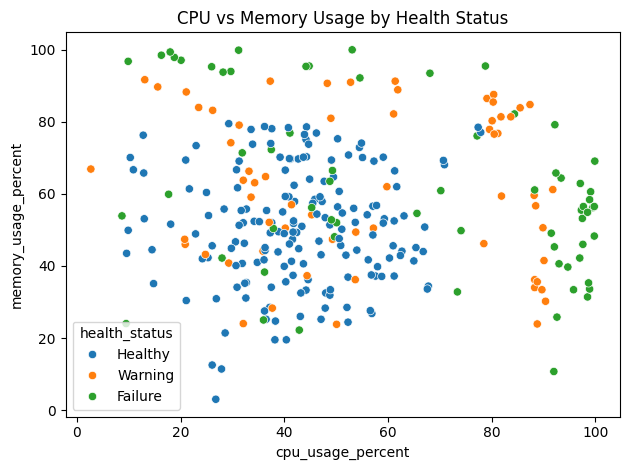

In [9]:
sns.scatterplot(data=df,
                x="cpu_usage_percent",
                y="memory_usage_percent",
                hue="health_status")
plt.title("CPU vs Memory Usage by Health Status")
plt.tight_layout()

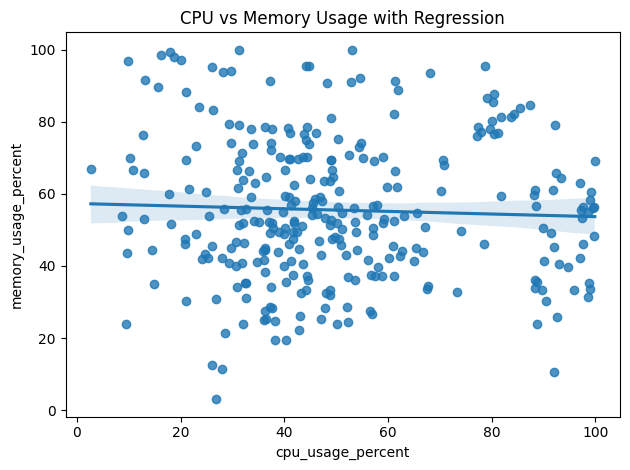

In [10]:
sns.regplot(data=df,
            x="cpu_usage_percent",
            y="memory_usage_percent")
plt.title("CPU vs Memory Usage with Regression")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'CPU Usage (%)')

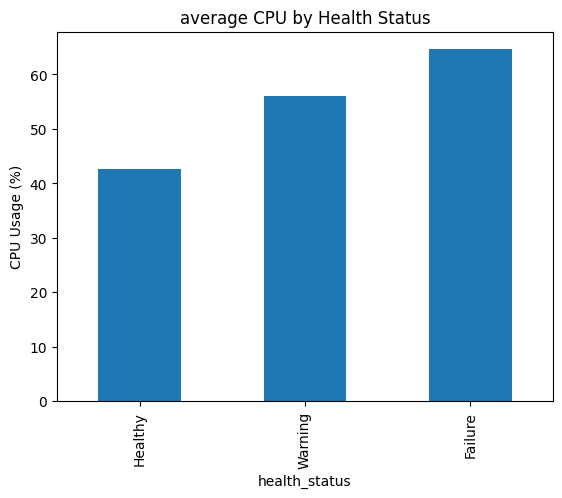

In [11]:
avg_cpu = df.groupby("health_status")["cpu_usage_percent"].mean()
avg_cpu.plot(kind="bar", title="average CPU by Health Status")
plt.ylabel("CPU Usage (%)")

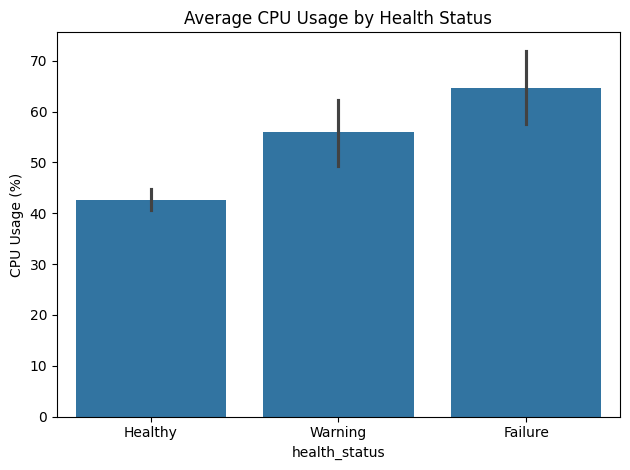

In [12]:
sns.barplot(data=df,
            x="health_status",
            y="cpu_usage_percent",
            estimator="mean")
plt.title("Average CPU Usage by Health Status")
plt.ylabel("CPU Usage (%)")
plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Uptime Over Time by Host')

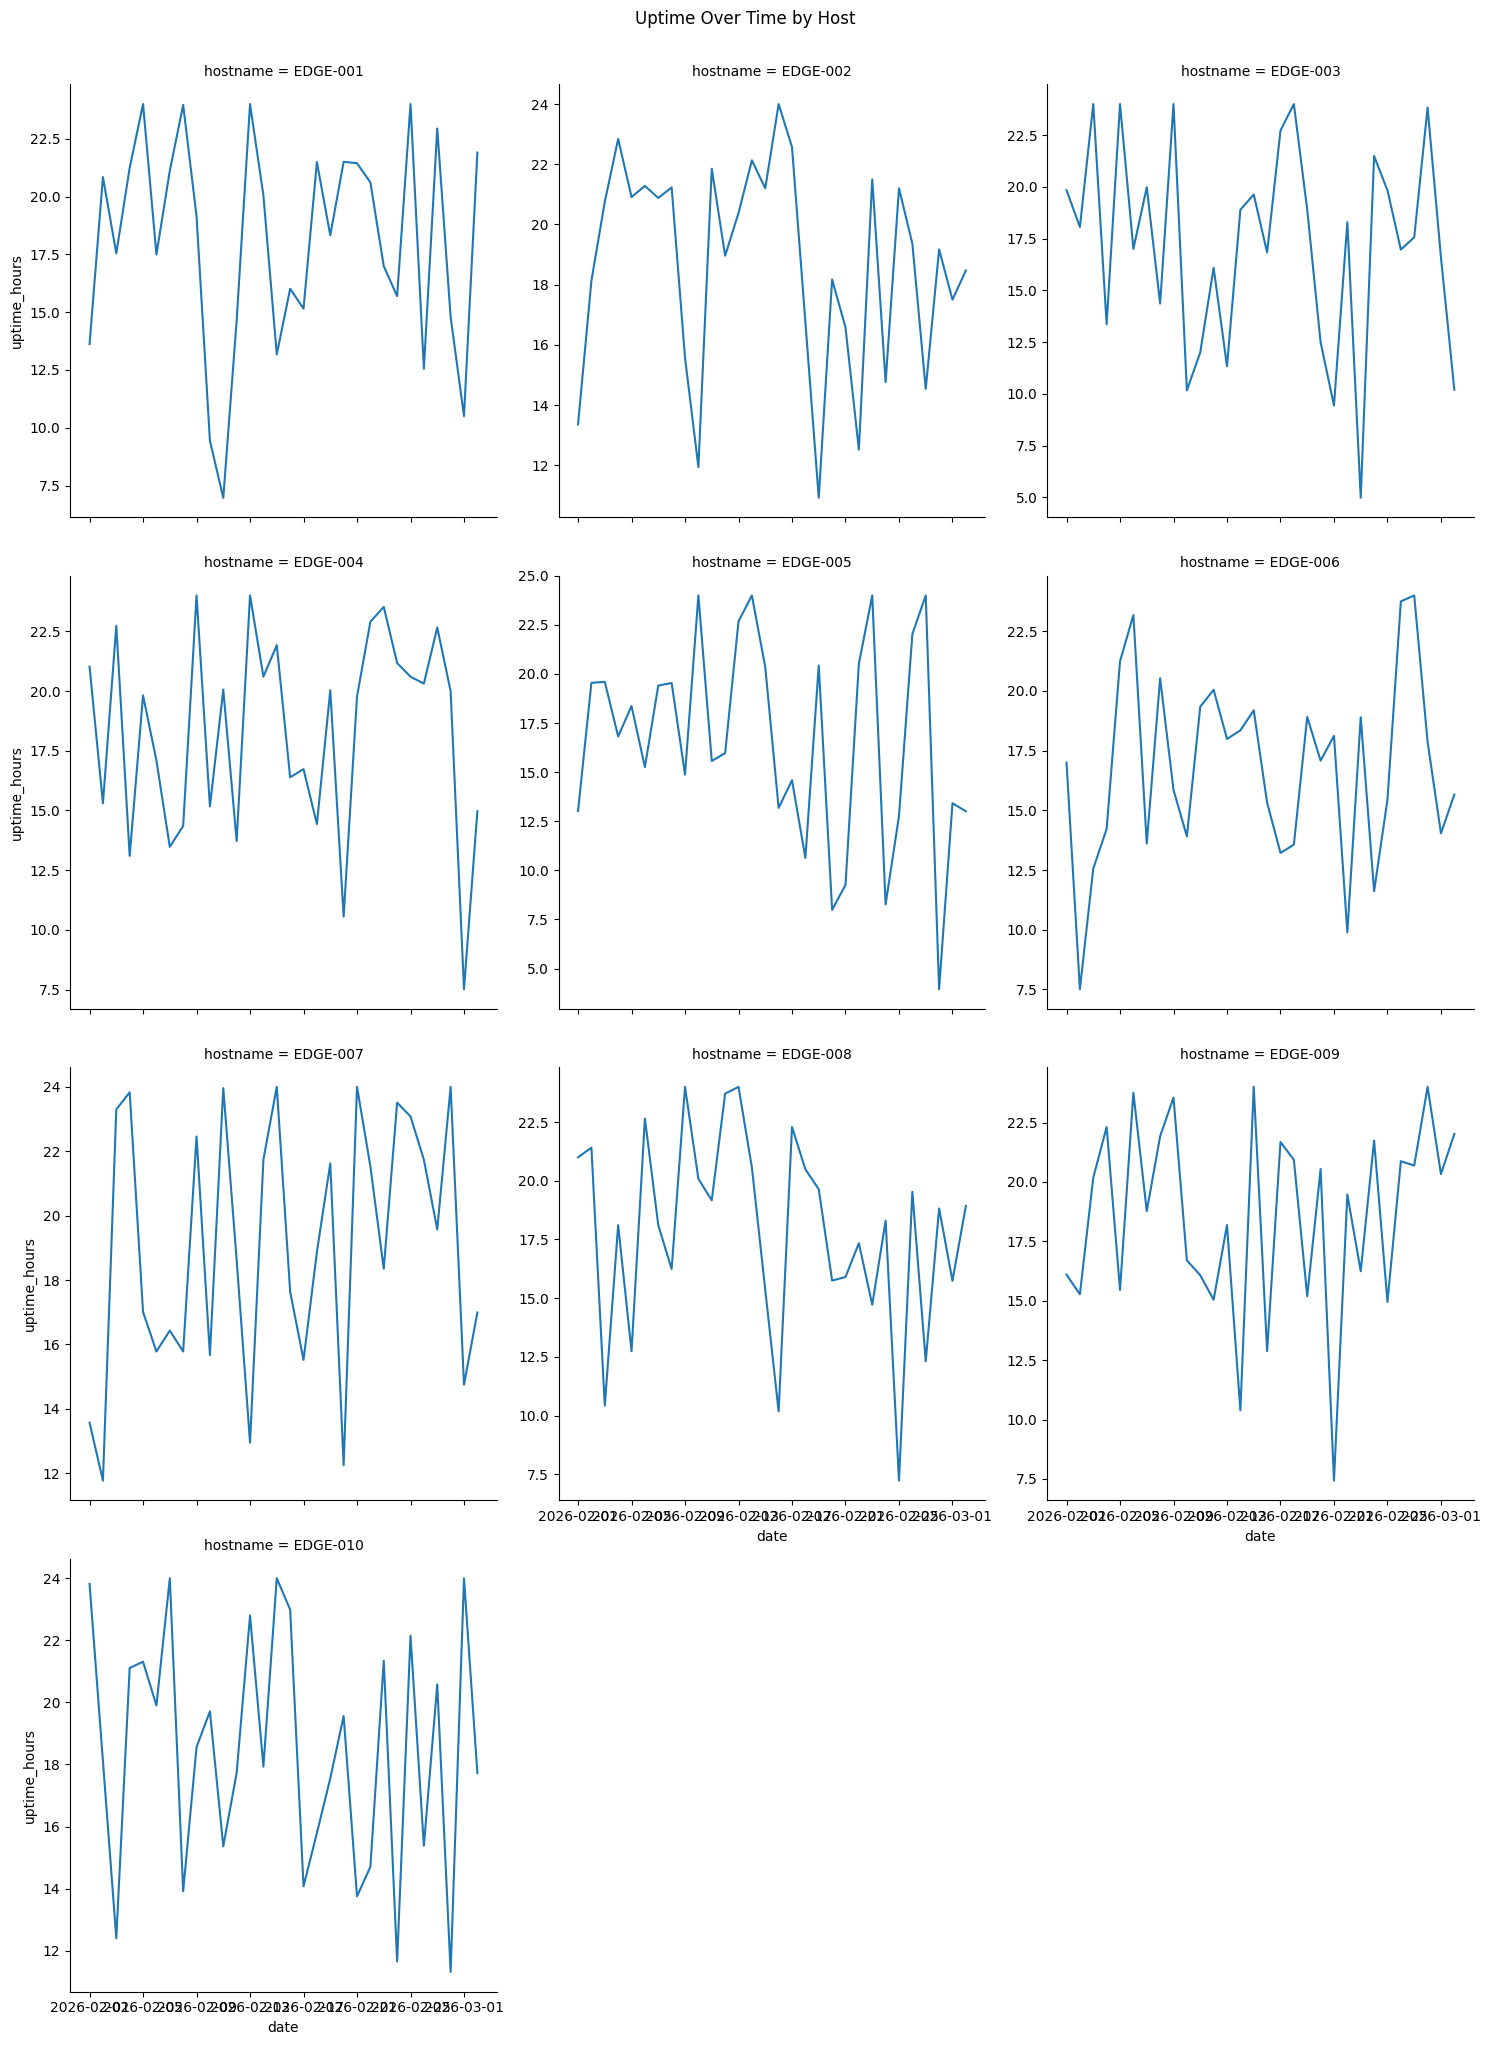

In [13]:
grid = sns.relplot(data=df.reset_index(),
                   x="date",
                   y="uptime_hours",
                   col="hostname",
                   kind="line",
                   col_wrap=3,
                   facet_kws={"sharey": False})
grid.fig.suptitle("Uptime Over Time by Host", y=1.02)

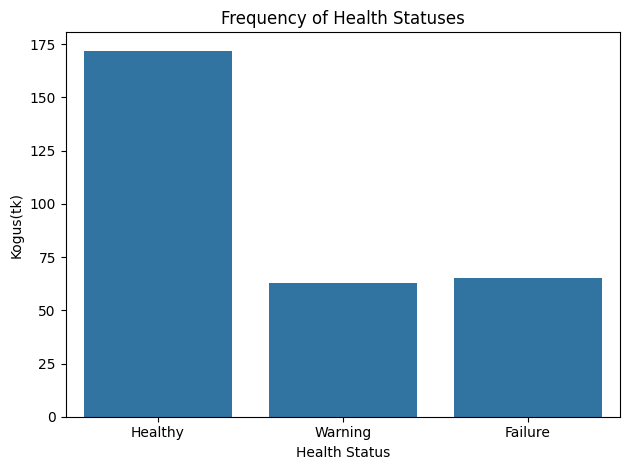

In [14]:
sns.countplot(data=df,
              x="health_status")
plt.title("Frequency of Health Statuses")
plt.xlabel("Health Status")
plt.ylabel("Kogus(tk)")
plt.tight_layout()
plt.show()

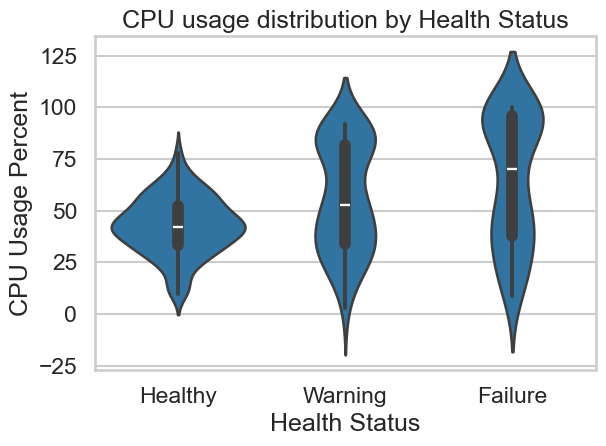

In [15]:
sns.set_style("whitegrid")
sns.set_context("talk")
sns.violinplot(data=df,
               x="health_status",
               y="cpu_usage_percent")
plt.title("CPU usage distribution by Health Status")
plt.xlabel("Health Status")
plt.ylabel("CPU Usage Percent")
plt.tight_layout()
plt.show()

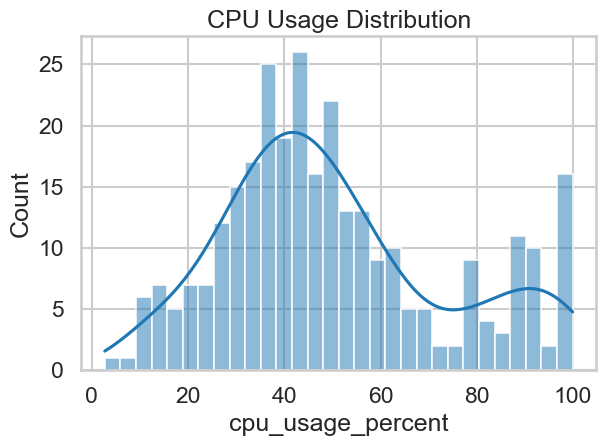

In [16]:
sns.histplot(data=df,
             x="cpu_usage_percent",
             bins=30,
             kde=True)
plt.title("CPU Usage Distribution")
plt.tight_layout()
plt.savefig("CPU_Usage_Distribution_SmallDataset.png", dpi=300)